2025-08-10 23:36:32 — INFO — Notebook start.
2025-08-10 23:36:32 — INFO — Installing python-dotenv (missing)
2025-08-10 23:36:33 — INFO — Installing Pillow (missing)
2025-08-10 23:36:34 — INFO — GenAI backend: Dev API
2025-08-10 23:36:34 — INFO — GLAS dataset found at D:\Projects\gemini_image_segmentation\data\GLAS
2025-08-10 23:36:34 — INFO — Scanning filesystem for image-mask pairs...
2025-08-10 23:36:34 — INFO — 165 total image-mask pairs collected for segmentation.
2025-08-10 23:36:34 — INFO — Selected sample image: train_75.bmp
2025-08-10 23:36:34 — INFO — Starting Gemini API call.
2025-08-10 23:36:34 — INFO — Sending prompt to model: Give the segmentation masks for colorectal glands in this histology slide. Output a JSON list of segmentation masks where each entry contains the 2D bounding box in the key "box_2d", the segmentation mask in key "mask", and the text label in the key "label". For each mask, use the label "colorectal gland".
2025-08-10 23:36:34 — INFO — AFC is enabled 

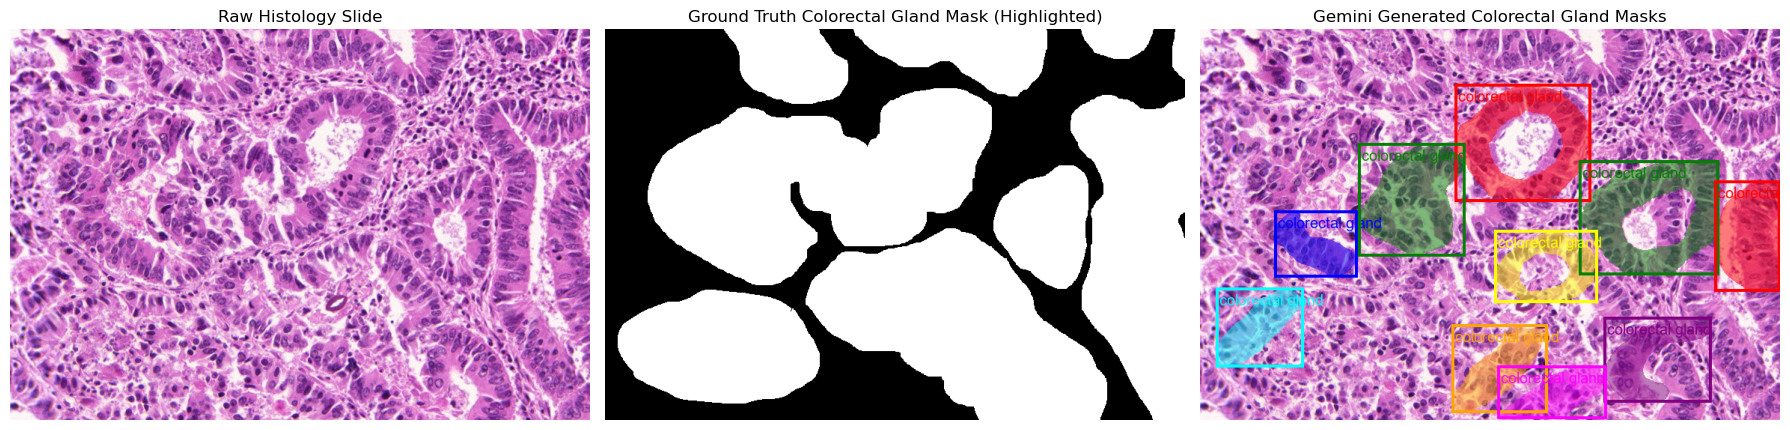

'\n✅ Environment verified, GLAS dataset indexed by filename convention.\nGemini smoke-test executed with a prompt for histology gland segmentation.\nNext step: Analyze results.\n'

In [7]:
# %% [markdown]
"""
# 02 Gland Segmentation · **GLAS Edition** (uses `environment.yml`)

*Last sync 10 Aug 2025* This script adapts the segmentation workflow for the GLAS
(Gland Segmentation in Colon Histology Images) dataset. It calls the Gemini API to identify
and mask all colorectal glands in histology slides.
- `gemini-2.5-flash` model
- Thinking disabled (`thinking_budget=0`)
- A clear, conversational prompt requesting a JSON list of masks for a specific pathology.
- **Correctly parses the API's output of multiple masks within bounding boxes.**
- **Visualizes the final masks overlaid on the original image.**

**Changelog (Adapted for GLAS)**
* **MODIFIED** dataset paths to point to the GLAS data structure (`data/GLAS/`).
* **REPLACED** CSV-based data loading with direct filesystem scanning to identify image/mask pairs based on the `_anno.bmp` naming convention.
* **REMOVED** the optional validation scan, as filesystem scanning is now the primary data collection method.
* **MODIFIED** the `PROMPT` to be more descriptive and lowered the `temperature` to improve accuracy.
* **RENAMED** variables and log messages for clarity (e.g., `histology_slide`, `gland_mask`).
* **VERIFIED** that the ground truth visualization correctly highlights any non-black pixels in the annotation mask.
* **MODIFIED** the `gemini_seg` function to handle `.bmp` files.
"""

# %%
# ---------- Preamble
import sys, logging, os, subprocess, importlib.util, json, io, random, base64, dataclasses
from datetime import datetime
from pathlib import Path
from typing import Tuple, Optional, List
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageColor, UnidentifiedImageError
from tqdm import tqdm

assert sys.version_info >= (3, 11), (
    f"Python 3.11+ required, found {sys.version.split()[0]}")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.info("Notebook start.")

# %%
# ---------- Ensure helper packages

def _ensure(pkg: str):
    """Checks if a package is installed and installs it if not."""
    if importlib.util.find_spec(pkg) is None:
        logging.info("Installing %s (missing)", pkg)
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

# MODIFIED: pandas is no longer strictly necessary but kept for potential future use
for extra in ("python-dotenv", "tqdm", "matplotlib", "numpy", "Pillow", "pandas"):
    _ensure(extra)

# %%
# ---------- GenAI client
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=False)

from google import genai
from google.genai import types
from google.genai.types import GenerateContentConfig, Part, ThinkingConfig

if not os.getenv("GOOGLE_API_KEY"):
    raise ValueError("GOOGLE_API_KEY not found. Ensure it is in your .env file.")

client = genai.Client()
logging.info("GenAI backend: %s", "Vertex" if client.vertexai else "Dev API")

# %%
# ---------- Configuration
# MODIFIED: Changed target to "colorectal gland".
SEGMENTATION_TARGET = "colorectal gland"

# MODIFIED: Point to the GLAS dataset directory.
dataset_dir = Path("data/GLAS").expanduser().resolve()

if not dataset_dir.is_dir():
    logging.error("GLAS directory not found at the specified path.")
    raise FileNotFoundError(
        f"Expected 'GLAS' directory at {dataset_dir}. "
        "Please ensure the GLAS dataset is correctly placed."
    )
logging.info("GLAS dataset found at %s", dataset_dir)


# %%
# ---------- Collect Image-Mask Pairs from Filesystem

logging.info("Scanning filesystem for image-mask pairs...")

# 1. Get all .bmp files from the directory
all_bmp_files = list(dataset_dir.glob("*.bmp"))

# 2. Isolate the source images (those that are NOT annotation masks)
source_images = [
    f for f in all_bmp_files if not f.name.endswith("_anno.bmp")
]

# 3. Pair source images with their corresponding masks
dataset = []
for img_path in source_images:
    # Construct the expected mask path
    mask_name = f"{img_path.stem}_anno.bmp"
    mask_path = img_path.with_name(mask_name)

    # Check if the corresponding mask file actually exists
    if mask_path.exists():
        dataset.append((img_path, mask_path))
    else:
        logging.warning("Found image '%s' but its mask was missing.", img_path.name)

assert dataset, "No image-mask pairs found. Check file naming and directory structure."
logging.info(
    "%d total image-mask pairs collected for segmentation.", len(dataset)
)


# %%
# ---------- Segmentation Utils

@dataclasses.dataclass(frozen=True)
class SegmentationMask:
    """A dataclass to hold a single segmentation mask's data."""
    y0: int
    x0: int
    y1: int
    x1: int
    mask: np.ndarray # Full-size mask [img_height, img_width] with values 0..255
    label: str

def parse_json(json_output: str) -> str:
    """Cleans the model's JSON output by removing markdown fencing."""
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line.strip() == "```json":
            json_content = "\n".join(lines[i+1:])
            closing_fence_index = json_content.find("```")
            if closing_fence_index != -1:
                json_content = json_content[:closing_fence_index]
            return json_content.strip()
    return json_output.strip()

def parse_segmentation_masks(
    predicted_str: str, *, img_height: int, img_width: int
) -> list[SegmentationMask]:
    """Parses the model's JSON output into a list of SegmentationMask objects."""
    cleaned_json = parse_json(predicted_str)
    if not cleaned_json:
        logging.warning("Parsing model output resulted in an empty string.")
        return []

    try:
        items = json.loads(cleaned_json)
    except json.JSONDecodeError as e:
        logging.error(f"Failed to decode JSON: {e}")
        logging.error(f"Problematic string after cleaning: {cleaned_json}")
        return []

    masks = []
    for item in items:
        try:
            abs_y0 = int(item["box_2d"][0] / 1000 * img_height)
            abs_x0 = int(item["box_2d"][1] / 1000 * img_width)
            abs_y1 = int(item["box_2d"][2] / 1000 * img_height)
            abs_x1 = int(item["box_2d"][3] / 1000 * img_width)

            if abs_y0 >= abs_y1 or abs_x0 >= abs_x1:
                logging.warning("Skipping item with invalid bounding box: %s", item["box_2d"])
                continue

            label = item["label"]
            png_b64_str = item["mask"]

            if not png_b64_str.startswith("data:image/png;base64,"):
                logging.warning("Skipping item with invalid mask format for label '%s'", label)
                continue

            png_bytes = base64.b64decode(png_b64_str.removeprefix("data:image/png;base64,"))
            partial_mask_img = Image.open(io.BytesIO(png_bytes))

            bbox_height = abs_y1 - abs_y0
            bbox_width = abs_x1 - abs_x0
            if bbox_height < 1 or bbox_width < 1:
                logging.warning("Skipping item with zero-area bounding box for label '%s'", label)
                continue

            resized_mask = partial_mask_img.resize((bbox_width, bbox_height), resample=Image.Resampling.BILINEAR)
            full_mask_np = np.zeros((img_height, img_width), dtype=np.uint8)
            full_mask_np[abs_y0:abs_y1, abs_x0:abs_x1] = np.array(resized_mask)

            masks.append(SegmentationMask(abs_y0, abs_x0, abs_y1, abs_x1, full_mask_np, label))
        except (KeyError, IndexError, TypeError, base64.binascii.Error, UnidentifiedImageError) as e:
            logging.error(f"Skipping malformed item in JSON response: {item}. Error: {e}")
            continue
    return masks

def overlay_mask_on_img(img: Image.Image, mask: np.ndarray, color: str, alpha: float = 0.5) -> Image.Image:
    """Overlays a single mask onto a PIL Image."""
    color_rgb = ImageColor.getrgb(color)
    img_rgba = img.convert("RGBA")
    overlay_color_rgba = color_rgb + (int(alpha * 255),)

    colored_mask_layer_np = np.zeros((img.height, img.width, 4), dtype=np.uint8)
    mask_binary = mask > 127
    colored_mask_layer_np[mask_binary] = overlay_color_rgba
    colored_mask_layer_pil = Image.fromarray(colored_mask_layer_np, 'RGBA')

    return Image.alpha_composite(img_rgba, colored_mask_layer_pil)

def plot_segmentation_masks(img: Image.Image, segmentation_masks: list[SegmentationMask]) -> Image.Image:
    """Draws all masks, bounding boxes, and labels on an image."""
    if not segmentation_masks:
        return img.convert("RGB")

    colors = ["red", "green", "blue", "yellow", "purple", "orange", "cyan", "magenta"]
    try:
        font = ImageFont.truetype("arial.ttf", size=20)
    except IOError:
        logging.warning("Arial font not found, using default. Labels may be small.")
        font = ImageFont.load_default()

    img_with_masks = img.copy()
    for i, seg_mask in enumerate(segmentation_masks):
        color = colors[i % len(colors)]
        img_with_masks = overlay_mask_on_img(img_with_masks, seg_mask.mask, color)

    draw = ImageDraw.Draw(img_with_masks)
    for i, seg_mask in enumerate(segmentation_masks):
        color = colors[i % len(colors)]
        box = ((seg_mask.x0, seg_mask.y0), (seg_mask.x1, seg_mask.y1))
        draw.rectangle(box, outline=color, width=4)
        if seg_mask.label:
            text_position = (seg_mask.x0 + 5, seg_mask.y0 + 5)
            draw.text(text_position, seg_mask.label, fill=color, font=font)

    return img_with_masks.convert("RGB")


# %%
# ---------- Gemini smoke-test (Refactored)

MODEL_NAME = "gemini-2.5-flash"
# MODIFIED: Prompt updated to be more descriptive for better accuracy.
PROMPT = (
    f'Give the segmentation masks for {SEGMENTATION_TARGET}s in this histology slide. '
    'Output a JSON list of segmentation masks where each entry contains the 2D bounding box in the key "box_2d", '
    'the segmentation mask in key "mask", and the text label in the key "label". '
    f'For each mask, use the label "{SEGMENTATION_TARGET}".'
)


def gemini_seg(image_obj: Image.Image) -> Tuple[list[SegmentationMask], float]:
    """
    Sends a PIL Image object to Gemini and returns a list of SegmentationMasks.

    Args:
        image_obj: A PIL.Image.Image object to be segmented.

    Returns:
        A tuple containing:
        - A list of SegmentationMask objects.
        - The latency of the API call in seconds.
    """
    logging.info("Starting Gemini API call.")
    original_width, original_height = image_obj.size
    
    try:
        # 1. Copy the image to avoid modifying the original object
        img_for_api = image_obj.copy()

        # 2. Resize for the API call if necessary
        max_dim = 1024
        if img_for_api.height > max_dim or img_for_api.width > max_dim:
            img_for_api.thumbnail((max_dim, max_dim))
            logging.info(f"Resized image from {original_width}x{original_height} to {img_for_api.size} for API call.")

        # 3. Convert the (potentially resized) PIL image to bytes
        with io.BytesIO() as img_byte_arr:
            # Save as PNG for API compatibility, even if original is BMP
            img_for_api.save(img_byte_arr, format='PNG')
            img_bytes = img_byte_arr.getvalue()

        # 4. Define the generation configuration with safety settings disabled
        safety_settings=[
            types.SafetySetting(
                category=types.HarmCategory.HARM_CATEGORY_HARASSMENT,
                threshold=types.HarmBlockThreshold.BLOCK_NONE,
            ),
            types.SafetySetting(
                category=types.HarmCategory.HARM_CATEGORY_HATE_SPEECH,
                threshold=types.HarmBlockThreshold.BLOCK_NONE,
            ),
            types.SafetySetting(
                category=types.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT,
                threshold=types.HarmBlockThreshold.BLOCK_NONE,
            ),
            types.SafetySetting(
                category=types.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
                threshold=types.HarmBlockThreshold.BLOCK_NONE,
            ),
        ]
        
        # MODIFIED: Lowered temperature for more deterministic and precise output.
        gen_config = GenerateContentConfig(
            thinking_config=ThinkingConfig(thinking_budget=0),
            temperature=0.5,
            safety_settings=safety_settings
        )

        # 5. Create explicit Part objects for the request
        image_part = Part.from_bytes(data=img_bytes, mime_type='image/png')
        text_part = Part(text=PROMPT)
        logging.info("Sending prompt to model: %s", PROMPT)

        # 6. Send the request
        start_time = datetime.now()
        response = client.models.generate_content(
            model=MODEL_NAME,
            contents=[image_part, text_part],
            config=gen_config,
        )
        latency = (datetime.now() - start_time).total_seconds()
        logging.info("Gemini latency %.2fs", latency)

        # 7. Parse the response using the utility function
        logging.info("Received response from Gemini. Parsing masks...")
        masks = parse_segmentation_masks(
            response.text,
            img_height=original_height,
            img_width=original_width
        )
        logging.info("Found %d segmentation masks.", len(masks))
        return masks, latency

    except Exception as e:
        logging.error("An error occurred during the gemini_seg function.", exc_info=True)
        return [], 0.0

# %%
# ---------- Main Execution and Visualization ----------
# Select a random sample and open the image ONCE.
sample_img_path, sample_mask_path = random.choice(dataset)
logging.info("Selected sample image: %s", sample_img_path.name)
original_image = Image.open(sample_img_path)

# Execute the segmentation by passing the Image object
gemini_masks, _ = gemini_seg(original_image)

# Visualize the results
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# 1. Original Image
ax[0].imshow(original_image)
ax[0].set_title("Raw Histology Slide")
ax[0].axis("off")

# 2. Ground Truth Mask
try:
    ground_truth_mask_pil = Image.open(sample_mask_path)
    # VERIFIED: This logic correctly handles the "any non-black pixel" requirement.
    # Convert to numpy array, set any pixel > 0 to white (255), then display.
    ground_truth_mask_np = np.array(ground_truth_mask_pil)
    highlighted_mask_np = np.where(ground_truth_mask_np > 0, 255, 0).astype(np.uint8)
    highlighted_mask_pil = Image.fromarray(highlighted_mask_np)
    
    ax[1].imshow(highlighted_mask_pil, cmap='gray')
    ax[1].set_title(f"Ground Truth {SEGMENTATION_TARGET.title()} Mask (Highlighted)")
except FileNotFoundError:
    ax[1].text(0.5, 0.5, 'Mask Not Found', ha='center', va='center')
    ax[1].set_title("Ground Truth Mask (not found)")
ax[1].axis("off")

# 3. Gemini Generated Mask
if gemini_masks:
    composite_image = plot_segmentation_masks(original_image, gemini_masks)
    ax[2].imshow(composite_image)
    ax[2].set_title(f"Gemini Generated {SEGMENTATION_TARGET.title()} Masks")
else:
    ax[2].imshow(original_image)
    ax[2].text(0.5, 0.5, 'Mask Generation Failed', ha='center', va='center', color='red',
               bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5'))
    ax[2].set_title("Gemini (failed)")
ax[2].axis("off")

plt.tight_layout()
plt.show()

# %% [markdown]
"""
✅ Environment verified, GLAS dataset indexed by filename convention.
Gemini smoke-test executed with a prompt for histology gland segmentation.
Next step: Analyze results.
"""
